In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import pandas as pd
bike_data_raw = pd.read_csv('daily-bike-share.csv')
bike_data_raw

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,12/27/2012,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,728,12/28/2012,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,729,12/29/2012,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,730,12/30/2012,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


In [3]:
bike_data_raw['dteday'] = pd.to_datetime(bike_data_raw['dteday'])
display(bike_data_raw)
print(bike_data_raw.info())

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  rentals     731 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(9)
memory usage: 80.1 KB
None


In [4]:
bike_data = bike_data_raw.copy()
bike_data.drop(['instant', 'dteday', 'yr'], axis=1, inplace=True)
display(bike_data)

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...,...
726,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


In [5]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit']
target = 'rentals'

In [6]:
bike_data['difference_temp'] = (bike_data['atemp'] - bike_data['temp'])/bike_data['temp']
bike_data.drop(['atemp'], axis=1, inplace=True)
numeric_features = ['temp', 'difference_temp', 'hum', 'windspeed']

In [7]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=False)

In [8]:
from sklearn.model_selection import train_test_split

X = bike_data[numeric_features+categorical_features].copy()
y = bike_data[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

def main(regressor, params, pca=False):

    numeric_transformer = Pipeline(steps=[
        ('logtransformer', PowerTransformer()),
        ('standardscaler', StandardScaler()),
        ('polynomialfeatures', PolynomialFeatures())])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])
    
    if (pca):
        final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('pca', PCA(n_components=0.95)),
                                ('regressor', regressor)])
    else:
        final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('regressor', regressor)])

    final_polynomial_regression_gridsearch = GridSearchCV(final_pipeline,
                                                        params,
                                                        scoring='neg_mean_squared_error',
                                                        cv=cv)

    final_polynomial_regression_gridsearch.fit(X_train, y_train)
    print("\nNajlepsze hiperparametry:", final_polynomial_regression_gridsearch.best_params_, "\n")

    final_polynomial_regression_model = final_polynomial_regression_gridsearch.best_estimator_
    predictions = final_polynomial_regression_model.predict(X_test)
    print(f'RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}')
    return predictions

In [10]:
params_elastic_net = {'preprocessor__num__polynomialfeatures__degree': [1, 2, 3, 4, 5],
            'regressor__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
            'regressor__l1_ratio': np.arange(0, 1.1, 0.1)}


predictions_elastic_net = main(ElasticNet(), params_elastic_net)


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 1, 'regressor__alpha': 0.1, 'regressor__l1_ratio': np.float64(0.4)} 

RMSE: 483.93794192975804


In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

def show_metrics(predictions):
    print(f'R^2: {r2_score(y_test, predictions)}')
    print(f'MAE: {mean_absolute_error(y_test, predictions)}')
    print(f'MAPE: {mean_absolute_percentage_error(y_test, predictions)}')

In [12]:
import matplotlib.pyplot as plt

def plot_predicted_vs_true(predictions):
    plt.scatter(x = predictions, y = y_test, alpha=0.25)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Prediction')
    plt.ylabel('True value')
    plt.title(f'Predicted vs true values')
    plt.show()

In [13]:
def plot_residuals(predictions):
    errors = predictions - y_test
    plt.scatter(x = y_test, y = errors, alpha=0.25)
    plt.axhline(0, color="r", linestyle="--")
    plt.xlabel('True Value test')
    plt.ylabel('Residual')
    plt.title(f'Plot of residuals')
    plt.show()

In [14]:
def plot_residuals_hist(predictions):
    errors = predictions - y_test
    plt.hist(errors, bins = 20)
    plt.axvline(errors.mean(), color='k', linestyle='dashed', linewidth=1)
    plt.title(f'Histogram of residuals, errors mean = {np.round(errors.mean(), 2)}')
    plt.show()

In [15]:
def plot_metrics(predictions):
    plot_predicted_vs_true(predictions)
    plot_residuals(predictions)
    plot_residuals_hist(predictions)

In [16]:
show_metrics(predictions_elastic_net)

R^2: 0.5246818851782761
MAE: 348.5851938306619
MAPE: 0.8593319615123969


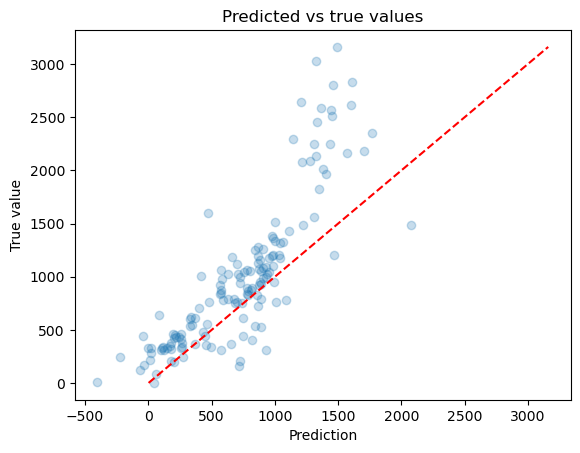

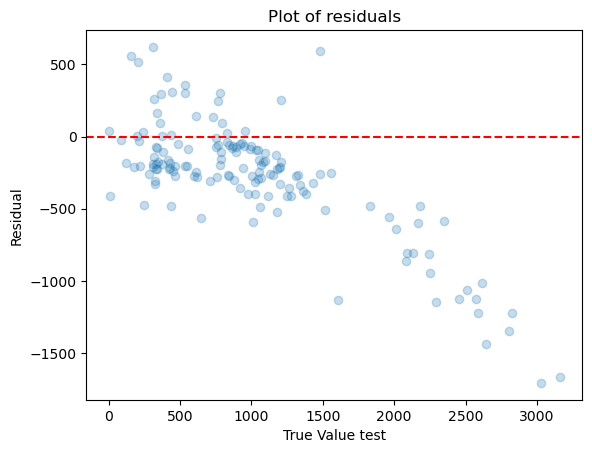

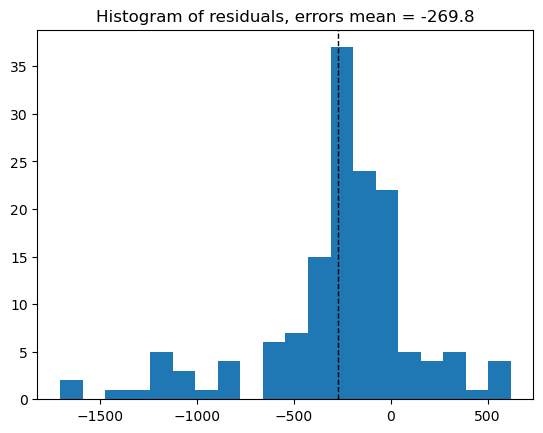

In [17]:
plot_metrics(predictions_elastic_net)

W porównaiu do pierwszego modelu obecny znacznie lepiej przewiduje dane. Świadczą o tym metryki:
- błąd średniokwadratowy zmniejszył się z 630,13 do 483,94
- R^2 wzrosło z 0,31 do 0,52
- MAE z 404,83 spadło na 348,59
- MAPE spadło z 298,6% na 85,9%
Powyższe metryki są znacznie lepsze, jednak nadal model nie jest dobry do wykorzystania do przewidywania ilości wypożyczeń, a przynajmniej nie w pełnym zakresie wartości, o czym świadczy dalsza ocena wizualizacyjna. 

Na wykresach widać sporą poprawę w stosunku do pierwszego modedelu. Na pierwszym widać, że wartości są znacznie bliżej linii referencyjnej. Oczywiście większe wartości nadal odbiegają od niej znacząco, jednak są one w mniejszości do reszty wyników, więc w mniejszy sposób wpływają na finalną ocenę. To samo widać na wykresie reszt, większość wartości w mniejszym stopniu odbiega od zera, z wyjatkiem większych wartości, dla których model niedoszacowuje wyników. Histogram błędów jest przesunięty w lewo ze średnią -269,8 co świadczy o niedoszacowaniach modelu. Na wynik na pewno mają wpływ duże wartości odstające.

In [18]:
from sklearn.ensemble import RandomForestRegressor

params_random_forest = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__max_depth': [1, 5, 10, 15, 20, 25, 30],
}


predictions_random_forest = main(RandomForestRegressor(random_state=42), params_random_forest)


Najlepsze hiperparametry: {'regressor__max_depth': 20, 'regressor__n_estimators': 100} 

RMSE: 350.756685478521


In [19]:
show_metrics(predictions_random_forest)

R^2: 0.7503009243958925
MAE: 252.4808584913763
MAPE: 1.075076436361111


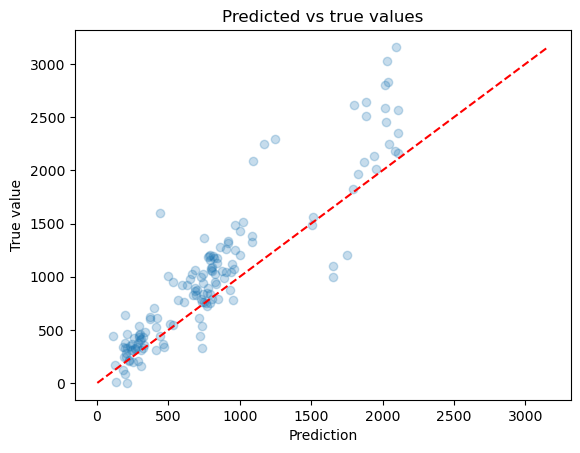

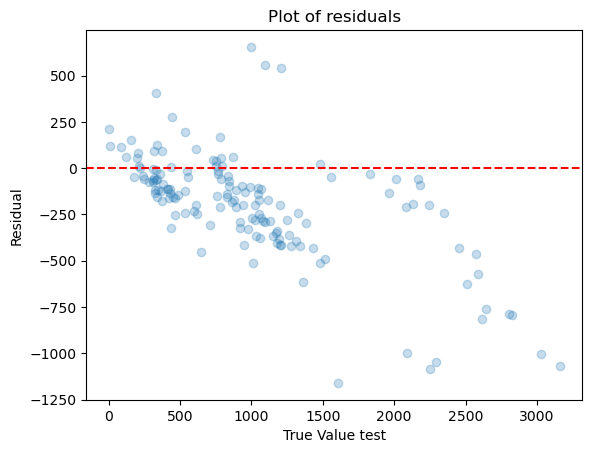

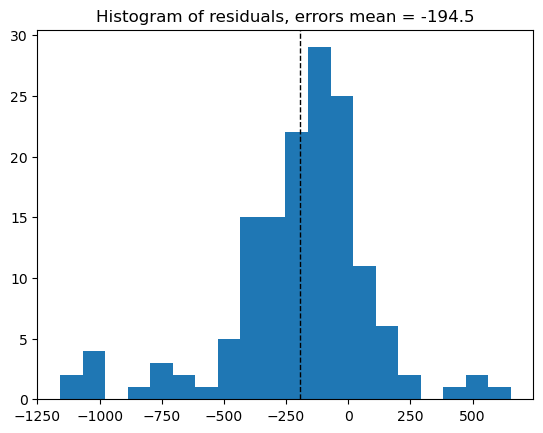

In [20]:
plot_metrics(predictions_random_forest)

Wykorzystanie RandomForestRegressor znacznie polepszyło wyniki. W tym przypadku błąd średniokwadratowy spadł do 350,76, R^2 wynosi 0,75, MAE 252,48, natomiast MAPE spadło do 10,8%.
Znaczącą różnice widać również na wykresach. Na pierwszym widać, że nie ma już takich różnic jak wcześniej przy dużych wartościach, co oznacza lepsze dopasowanie modelu w całym zakresie danych. Pozostałe wykresy również świadczą o poprawie predykcji.

In [21]:
from sklearn.ensemble import GradientBoostingRegressor
params = {
    'regressor__n_estimators': [150, 200, 250, 300],
    'regressor__max_depth': [1, 5, 10],
}
predictions_gradient_boosting = main(GradientBoostingRegressor(), params)


Najlepsze hiperparametry: {'regressor__max_depth': 5, 'regressor__n_estimators': 200} 

RMSE: 368.38697037683556


In [22]:
show_metrics(predictions_gradient_boosting)

R^2: 0.7245685415915002
MAE: 276.7475581182024
MAPE: 0.7793687938357517


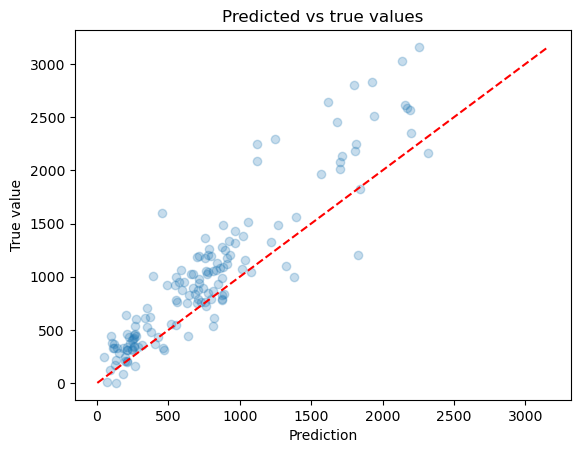

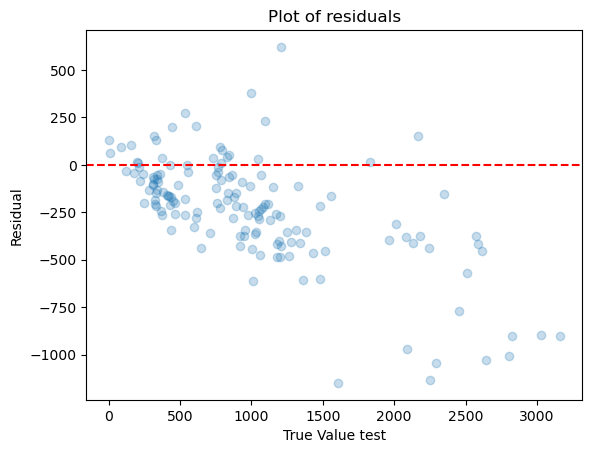

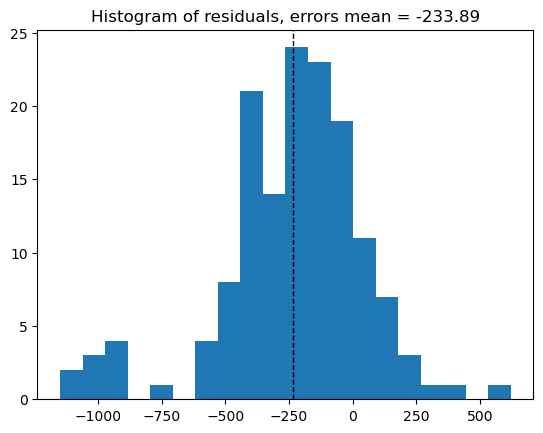

In [23]:
plot_metrics(predictions_gradient_boosting)

GradientBoostingRegressor poradził sobie nieco gorzej niż Random Forest, jednak też znacznie lepiej niż poprzednie modele.
Podsumowując najlepszy okazał się RandomForestRegressor z głębokością drzewa wynoszącą 20 oraz liczbą drzew w ilości 100.

In [26]:
predictions_elastic_net_with_pca = main(ElasticNet(), params_elastic_net, pca=True)
show_metrics(predictions_elastic_net_with_pca)


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 2, 'regressor__alpha': 10.0, 'regressor__l1_ratio': np.float64(1.0)} 

RMSE: 497.6175338208802
R^2: 0.4974302221079857
MAE: 331.3615304978075
MAPE: 0.8441973886145447


In [28]:
predictions_random_forest_with_pca = main(RandomForestRegressor(random_state=42), params_random_forest, pca=True)
show_metrics(predictions_random_forest_with_pca)


Najlepsze hiperparametry: {'regressor__max_depth': 20, 'regressor__n_estimators': 150} 

RMSE: 458.90572934710843
R^2: 0.5725828154901575
MAE: 322.94758593057236
MAPE: 1.747015803632896


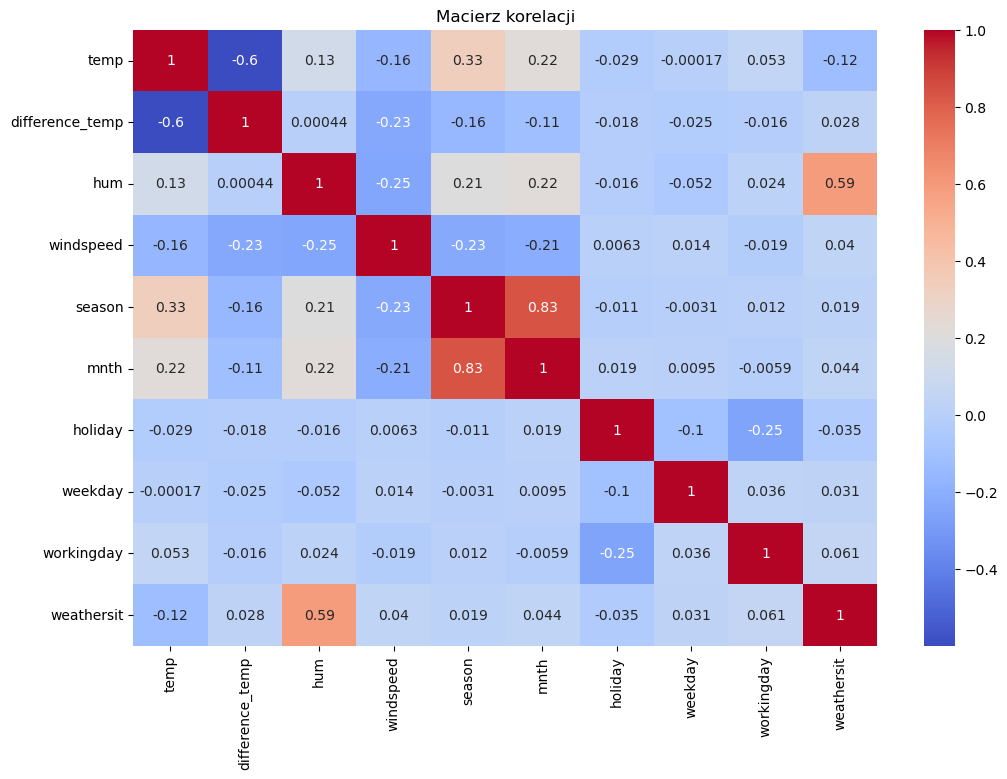

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Macierz korelacji")
plt.show()

PCA w przypdku analizowanego zbioru pogorszyło sytuację i nie powinno być wykorzystywane. Nie ma w zbiorze zbyt wielu silnych korelacji, więc tym bardziej nie jest konieczna ich redukcja przez PCA. Gorsze metryki otrzymano zarówno w przypadu wykorzystywania ElsticNet, jak i RandomForestRegressor.